# IOR Engine Comparison

Aggregates per-engine CSV files in this directory for Read and Write bandwidth.

CV% = σ / μ × 100 computed across iterations within each run and pooled across runs.

Currently includes: **POSIX**, **IL**. Additional engines can be added by appending matching CSVs.

In [1]:
import re
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns



Filename convention: `ior_{engine}_n-{N}_ppn-{PPN}_tx-{TX}_{timestamp}.csv`

Metadata (`engine`, `n`, `ppn`, `tx`, `run_id`) are extracted from each filename.

In [2]:
data_dir = Path(".")
csv_files = sorted(data_dir.glob("ior_*.csv"))
print(f"Found {len(csv_files)} CSV files")

frames = []
for f in csv_files:
    m = re.search(r'^ior_(\w+)_n-(\d+)_ppn-(\d+)_tx-(\w+)_(\d+)', f.stem)
    if not m:
        print(f"  skipping (no match): {f.name}")
        continue
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()
    df["engine"]    = m.group(1).upper()
    df["n"]         = int(m.group(2))
    df["ppn"]       = int(m.group(3))
    df["tx"]        = m.group(4).upper()
    df["timestamp"] = int(m.group(5))
    df["run_id"]    = f.stem
    df["filename"]  = f.name
    frames.append(df)

combined = pd.concat(frames, ignore_index=True)
combined["access"]   = combined["access"].str.strip().str.lower()
combined["bw_MiB_s"] = combined["bw(MiB/s)"]

print(f"Total rows : {len(combined)}")
print(f"Engines    : {combined['engine'].unique()}")
print(f"Configs    : n={combined['n'].unique()}, ppn={combined['ppn'].unique()}, tx={combined['tx'].unique()}")
print(f"Runs       : {combined['timestamp'].nunique()}")

Found 7 CSV files
  skipping (no match): ior_engine_combined.csv
Total rows : 40
Engines    : ['IL' 'POSIX']
Configs    : n=[1], ppn=[48], tx=['2M']
Runs       : 6


In [3]:
out_path = data_dir / "ior_engine_combined.csv"
combined.to_csv(out_path, index=False)
print(f"Saved → {out_path.resolve()}")

Saved → /Users/xmei/Documents/LDRD/pdsw26_daos-bench-res/results/aurora/ior/engine/ior_engine_combined.csv


## Load DAOS DFS (ior-rw) Data

Load matching config (`n=1, ppn=48, tx=2M`) from `../ior-rw-scaling/` so DFS write/read
data is available alongside POSIX and IL for the cold/warm check and bandwidth comparisons below.

In [4]:
rw_dir = Path("../ior-rw-scaling")

# Match same n/ppn/tx config as the POSIX runs
cfg_n   = combined["n"].iloc[0]
cfg_ppn = combined["ppn"].iloc[0]
cfg_tx  = combined["tx"].iloc[0]          # already uppercase (e.g. "2M") — keep case to match filenames
rw_pattern = f"ior_rw_n-{cfg_n}_ppn-{cfg_ppn}_tx-{cfg_tx}*.csv"
rw_files = sorted(rw_dir.glob(rw_pattern))
print(f"Found {len(rw_files)} ior-rw CSV files matching config: {rw_pattern}")

rw_frames = []
for f in rw_files:
    m = re.search(r'_n-(\d+)_ppn-(\d+)_tx-(\w+)_(\d+)', f.stem)
    if not m:
        continue
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()
    df["n"]         = int(m.group(1))
    df["ppn"]       = int(m.group(2))
    df["tx"]        = m.group(3).upper()
    df["timestamp"] = int(m.group(4))
    df["run_id"]    = f.stem
    rw_frames.append(df)

rw_combined = pd.concat(rw_frames, ignore_index=True)
rw_combined["access"]   = rw_combined["access"].str.strip().str.lower()
rw_combined["bw_MiB_s"] = rw_combined["bw(MiB/s)"]

print(f"ior-rw rows : {len(rw_combined)}  ({rw_combined['run_id'].nunique()} runs, "
      f"{rw_combined.groupby('access')['iter'].nunique().to_dict()} iters per access)")

Found 1 ior-rw CSV files matching config: ior_rw_n-1_ppn-48_tx-2M*.csv
ior-rw rows : 20  (1 runs, {'read': 10, 'write': 10} iters per access)


## Write Bandwidth & Latency: Cold vs Warm (POSIX vs IL vs DFS)

Is the first iteration of each engine's write series (`iter == 0`, "cold") slower than
later iterations (`iter >= 1`, "warm")? A cold penalty would point to first-write
allocation cost (e.g. file/object creation) rather than steady-state throughput.

**Bandwidth** — checked across all three engines below; the pattern does **not** generalize:

- **IL**: cold is ~1.8x *slower* than warm — a real cold-start penalty.
- **POSIX**: cold is actually ~10% *faster* than warm — the opposite direction, and modest.
- **DFS**: cold and warm are within ~0.4% of each other — no effect.
- **Read** bandwidth (all three engines, checked but not shown as its own table) shows no
  cold/warm split either — ratios all within ~3% of 1.

**Latency** — POSIX and DFS track the bandwidth story (POSIX ~14% higher warm latency,
consistent with its slightly faster cold write; DFS flat, within ~1% either way). **IL is
the exception**: median write latency is ~15% *higher* in the warm phase, even though warm
bandwidth is ~1.8x higher — the opposite of what you'd expect if latency were simply
1/throughput. IOR's per-op `Latency` field isn't a direct inverse of aggregate bandwidth
here, so bandwidth and latency tell different (even opposite) stories for IL specifically.
Read latency shows no cold/warm split for any engine (within ~4%), matching the read
bandwidth result.

So the cold/warm gap is specific to IL's write path, not a general IOR or engine-agnostic
artifact — and for IL it shows up differently depending on which metric you look at.

In [5]:
cw_engines = ["POSIX", "IL", "DFS"]

def cold_warm_stats(access, metric="bw_MiB_s", unit_suffix="MiB_s"):
    frames = []
    for eng, grp in combined.groupby("engine"):
        sub = grp[grp["access"] == access].copy()
        sub["phase"]  = np.where(sub["iter"] == 0, "cold", "warm")
        sub["engine"] = eng
        frames.append(sub[["engine", "phase", metric]])

    dfs_sub = rw_combined[rw_combined["access"] == access].copy()
    dfs_sub["phase"]  = np.where(dfs_sub["iter"] == 0, "cold", "warm")
    dfs_sub["engine"] = "DFS"
    frames.append(dfs_sub[["engine", "phase", metric]])

    long_df = pd.concat(frames, ignore_index=True)
    stats = (
        long_df.groupby(["engine", "phase"])[metric]
        .agg(**{
            f"median_{unit_suffix}": "median", f"mean_{unit_suffix}": "mean",
            f"std_{unit_suffix}": "std", f"min_{unit_suffix}": "min",
            f"max_{unit_suffix}": "max", "n_iters": "count",
        })
        .reset_index()
    )
    return stats

cw_stats = cold_warm_stats("write")
for col in ["median_MiB_s", "mean_MiB_s", "std_MiB_s", "min_MiB_s", "max_MiB_s"]:
    cw_stats[col.replace("MiB_s", "GiB_s")] = cw_stats[col] / 1024

cw_pivot = cw_stats.pivot(index="engine", columns="phase", values="median_MiB_s").reindex(cw_engines)
cw_pivot["warm/cold"] = cw_pivot["warm"] / cw_pivot["cold"]
print("Write median BW (MiB/s) — cold (iter 0) vs warm (iter >= 1):")
print(cw_pivot.round(2))

# Sanity check: confirm read shows no comparable split for any engine.
read_cw_pivot = (
    cold_warm_stats("read")
    .pivot(index="engine", columns="phase", values="median_MiB_s")
    .reindex(cw_engines)
)
read_cw_pivot["warm/cold"] = read_cw_pivot["warm"] / read_cw_pivot["cold"]
print("\nRead median BW (MiB/s) — cold vs warm (for comparison, expect ~1.0x):")
print(read_cw_pivot.round(2))

display(
    cw_stats[["engine", "phase", "n_iters", "median_MiB_s", "median_GiB_s", "mean_MiB_s", "std_MiB_s", "min_MiB_s", "max_MiB_s"]]
    .sort_values(["engine", "phase"])
    .style
    .format({
        "median_MiB_s": "{:.1f}", "median_GiB_s": "{:.2f}", "mean_MiB_s": "{:.1f}",
        "std_MiB_s": "{:.1f}", "min_MiB_s": "{:.1f}", "max_MiB_s": "{:.1f}",
    })
    .set_caption("Write Bandwidth: Cold (iter 0) vs Warm (iter >= 1) — POSIX vs IL vs DFS")
    .hide(axis="index")
)

# --- Latency (ms) — same cold/warm split, mirrors the bandwidth check above ---
cw_lat_stats = cold_warm_stats("write", metric="Latency", unit_suffix="s")
for col in ["median_s", "mean_s", "std_s", "min_s", "max_s"]:
    cw_lat_stats[col.replace("_s", "_ms")] = cw_lat_stats[col] * 1000

cw_lat_pivot = cw_lat_stats.pivot(index="engine", columns="phase", values="median_ms").reindex(cw_engines)
cw_lat_pivot["warm/cold"] = cw_lat_pivot["warm"] / cw_lat_pivot["cold"]
print("\nWrite median latency (ms) — cold (iter 0) vs warm (iter >= 1):")
print(cw_lat_pivot.round(3))

# Sanity check: confirm read latency shows no comparable split for any engine.
read_cw_lat_pivot = (
    cold_warm_stats("read", metric="Latency", unit_suffix="s")
    .assign(median_ms=lambda d: d["median_s"] * 1000)
    .pivot(index="engine", columns="phase", values="median_ms")
    .reindex(cw_engines)
)
read_cw_lat_pivot["warm/cold"] = read_cw_lat_pivot["warm"] / read_cw_lat_pivot["cold"]
print("\nRead median latency (ms) — cold vs warm (for comparison):")
print(read_cw_lat_pivot.round(3))

display(
    cw_lat_stats[["engine", "phase", "n_iters", "median_ms", "mean_ms", "std_ms", "min_ms", "max_ms"]]
    .sort_values(["engine", "phase"])
    .style
    .format({
        "median_ms": "{:.2f}", "mean_ms": "{:.2f}",
        "std_ms": "{:.2f}", "min_ms": "{:.2f}", "max_ms": "{:.2f}",
    })
    .set_caption("Write Latency: Cold (iter 0) vs Warm (iter >= 1) — POSIX vs IL vs DFS")
    .hide(axis="index")
)

Write median BW (MiB/s) — cold (iter 0) vs warm (iter >= 1):
phase        cold       warm  warm/cold
engine                                 
POSIX      928.51     832.25       0.90
IL       88375.73  157433.50       1.78
DFS     136680.92  137203.54       1.00

Read median BW (MiB/s) — cold vs warm (for comparison, expect ~1.0x):
phase       cold      warm  warm/cold
engine                               
POSIX    3213.83   3113.74       0.97
IL      92958.16  93235.79       1.00
DFS     71486.95  71679.22       1.00


engine,phase,n_iters,median_MiB_s,median_GiB_s,mean_MiB_s,std_MiB_s,min_MiB_s,max_MiB_s
DFS,cold,1,136680.9,133.48,136680.9,nan,136680.9,136680.9
DFS,warm,9,137203.5,133.99,136119.9,1807.5,132360.1,137673.8
IL,cold,3,88375.7,86.30,88488.0,616.6,87935.2,89153.0
IL,warm,7,157433.5,153.74,157244.4,1245.4,155612.7,159401.0
POSIX,cold,3,928.5,0.91,918.6,46.4,868.1,959.3
POSIX,warm,7,832.3,0.81,813.2,33.2,749.3,841.4



Write median latency (ms) — cold (iter 0) vs warm (iter >= 1):
phase     cold    warm  warm/cold
engine                           
POSIX   4816.6  5504.6      1.143
IL        25.2    28.9      1.147
DFS       22.3    22.1      0.991

Read median latency (ms) — cold vs warm (for comparison):
phase     cold    warm  warm/cold
engine                           
POSIX   1413.4  1473.5      1.043
IL        49.1    49.1      1.000
DFS       42.5    42.4      0.998


engine,phase,n_iters,median_ms,mean_ms,std_ms,min_ms,max_ms
DFS,cold,1,22.30,22.30,nan,22.30,22.30
DFS,warm,9,22.10,22.28,0.28,22.00,22.80
IL,cold,3,25.20,24.97,0.78,24.10,25.60
IL,warm,7,28.90,28.97,0.21,28.70,29.30
POSIX,cold,3,4816.60,4897.87,223.38,4726.50,5150.50
POSIX,warm,7,5504.60,5619.21,242.21,5447.20,6135.40


## Median Bandwidth Comparison: POSIX vs IL vs DFS

Compare median Read/Write bandwidth side-by-side across POSIX, IL, and DFS
(DFS data loaded above from `../ior-rw-scaling/`).

In [6]:
# Compute median, mean, std, min, max per engine × access (POSIX + IL from combined, DFS from rw_combined)
engine_frames = []
for eng, grp in combined.groupby("engine"):
    stats = (
        grp.groupby("access")["bw_MiB_s"]
        .agg(median_MiB_s="median", mean_MiB_s="mean", std_MiB_s="std",
             min_MiB_s="min", max_MiB_s="max", n_iters="count")
        .reset_index()
        .assign(engine=eng)
    )
    engine_frames.append(stats)

rw_stats = (
    rw_combined.groupby("access")["bw_MiB_s"]
    .agg(median_MiB_s="median", mean_MiB_s="mean", std_MiB_s="std",
         min_MiB_s="min", max_MiB_s="max", n_iters="count")
    .reset_index()
    .assign(engine="DFS")
)
engine_frames.append(rw_stats)

cmp_df = pd.concat(engine_frames, ignore_index=True)
for col in ["median_MiB_s", "mean_MiB_s", "std_MiB_s", "min_MiB_s", "max_MiB_s"]:
    cmp_df[col.replace("MiB_s", "GiB_s")] = cmp_df[col] / 1024

cmp_df["cv_pct"] = cmp_df["std_MiB_s"] / cmp_df["mean_MiB_s"] * 100

# Speedup relative to POSIX median BW
posix_medians = cmp_df[cmp_df["engine"] == "POSIX"].set_index("access")["median_MiB_s"]
cmp_df["speedup"] = cmp_df.apply(
    lambda r: r["median_MiB_s"] / posix_medians[r["access"]] if r["engine"] != "POSIX" else np.nan,
    axis=1,
)

cfg = combined[["n", "ppn", "tx"]].iloc[0]
display(
    cmp_df[["engine", "access", "n_iters", "median_GiB_s", "mean_GiB_s", "std_GiB_s", "cv_pct", "speedup"]]
    .sort_values(["access", "engine"])
    .style
    .format({
        "median_GiB_s": "{:.2f}",
        "mean_GiB_s":   "{:.2f}",
        "std_GiB_s":    "{:.4f}",
        "cv_pct":       "{:.2f}%",
        "speedup":      lambda v: f"{v:.1f}×" if pd.notna(v) else "—",
    })
    .set_caption(f"Median BW: POSIX vs IL vs DAOS DFS  [n={cfg['n']}, ppn={cfg['ppn']}, tx={cfg['tx']}]")
    .hide(axis="index")
)


engine,access,n_iters,median_GiB_s,mean_GiB_s,std_GiB_s,cv_pct,speedup
DFS,read,10,69.94,69.92,0.2276,0.33%,22.6×
IL,read,10,91.01,91.00,3.8527,4.23%,29.5×
POSIX,read,10,3.09,3.02,0.2349,7.78%,—
DFS,write,10,133.73,132.98,1.6731,1.26%,164.1×
IL,write,10,152.97,133.42,32.4505,24.32%,187.7×
POSIX,write,10,0.81,0.83,0.0602,7.30%,—


## Combined IOR + fio Write Bandwidth

Adds fio `randwrite` results (DFS, dfuse/pvsync2 → POSIX, libioil/pvsync2 → IL) from `../../fio/engine/` alongside IOR Read/Write for a direct three-tool comparison.

In [7]:
import json

fio_dir = data_dir / "../../fio/engine"

FIO_ENGINES = {
    "DFS":   "fio_dfs_*.json",
    "POSIX": "fio_dfuse_pvsync2_*.json",
    "IL":    "fio_libioil_pvsync2_*.json",
}

fio_rows = []
for engine, pattern in FIO_ENGINES.items():
    for fpath in sorted(fio_dir.glob(pattern)):
        text = fpath.read_text()
        js = text.find("{")
        if js < 0:
            continue
        try:
            d = json.loads(text[js:])
            j = d["jobs"][0]
            bw_GiB_s = j["write"]["bw_bytes"] / 1024**3
            fio_rows.append({"engine": engine, "bw_GiB_s": bw_GiB_s})
        except Exception:
            continue

fio_df = pd.DataFrame(fio_rows)

fio_stats = (
    fio_df.groupby("engine")["bw_GiB_s"]
    .agg(median_GiB_s="median", min_GiB_s="min", max_GiB_s="max", n_iters="count")
    .reset_index()
)

print("fio write bandwidth (GiB/s):")
display(fio_stats.style.format({"median_GiB_s": "{:.2f}", "min_GiB_s": "{:.2f}", "max_GiB_s": "{:.2f}"}).hide(axis="index"))

fio write bandwidth (GiB/s):


engine,median_GiB_s,min_GiB_s,max_GiB_s,n_iters
DFS,88.06,79.37,88.99,10
IL,12.19,11.91,12.37,20
POSIX,39.29,37.22,39.52,12


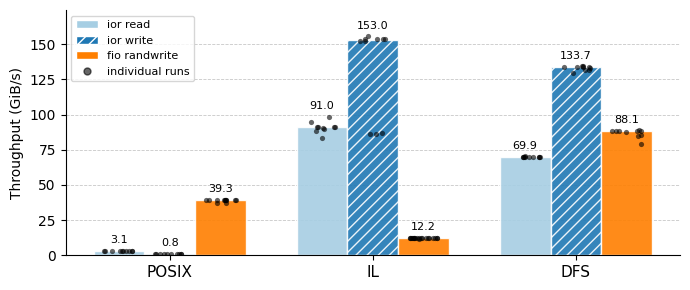

In [8]:
engines_order = ["POSIX", "IL", "DFS"]
paired = sns.color_palette("Paired", 12)

COLORS = {
    "ior read":      paired[0],  # light blue
    "ior write":     paired[1],  # dark blue
    "fio randwrite": paired[7],  # dark orange
}
LEGEND_ORDER = ["ior read", "ior write", "fio randwrite"]
HATCH = {"ior write": "///"}  # white hatch lines (follows edgecolor="white" below)

def engine_raw_values(engine):
    """Per-engine raw throughput values (GiB/s) per series — bar height is their median,
    all points (cold + warm iterations pooled for ior write) are drawn as scatter."""
    if engine == "DFS":
        read_vals  = rw_combined.loc[rw_combined["access"] == "read",  "bw_MiB_s"].to_numpy() / 1024
        write_vals = rw_combined.loc[rw_combined["access"] == "write", "bw_MiB_s"].to_numpy() / 1024
    else:
        eng_grp    = combined[combined["engine"] == engine]
        read_vals  = eng_grp.loc[eng_grp["access"] == "read",  "bw_MiB_s"].to_numpy() / 1024
        write_vals = eng_grp.loc[eng_grp["access"] == "write", "bw_MiB_s"].to_numpy() / 1024
    fio_vals = fio_df.loc[fio_df["engine"] == engine, "bw_GiB_s"].to_numpy()
    return {"ior read": read_vals, "ior write": write_vals, "fio randwrite": fio_vals}

x     = np.arange(len(engines_order))
bar_w = 0.25
offsets = np.linspace(-(len(LEGEND_ORDER) - 1) / 2, (len(LEGEND_ORDER) - 1) / 2, len(LEGEND_ORDER)) * bar_w

fig, ax = plt.subplots(figsize=(7, 3))
rng = np.random.default_rng(0)

for xi, engine in zip(x, engines_order):
    raw = engine_raw_values(engine)
    for offset, label in zip(offsets, LEGEND_ORDER):
        vals   = raw[label]
        xpos   = xi + offset
        median = np.median(vals)

        ax.bar(xpos, median, width=bar_w, color=COLORS[label], hatch=HATCH.get(label, ""),
               edgecolor="white", alpha=0.9, zorder=2)

        jitter = rng.uniform(-bar_w * 0.3, bar_w * 0.3, size=len(vals))
        ax.scatter(xpos + jitter, vals, color="black", s=14, zorder=3, alpha=0.6, linewidths=0)

        ax.annotate(f"{median:.1f}", xy=(xpos, max(vals.max(), median)), xytext=(0, 4),
                    textcoords="offset points", ha="center", va="bottom", fontsize=8, color="black")

ax.set_xticks(x)
ax.set_xticklabels(engines_order, fontsize=11)
ax.set_ylabel("Throughput (GiB/s)")
ax.margins(y=0.12)

from matplotlib.patches import Patch
from matplotlib.lines import Line2D
handles = [Patch(facecolor=COLORS[l], hatch=HATCH.get(l, ""), edgecolor="white", label=l) for l in LEGEND_ORDER]
handles.append(Line2D([0], [0], marker="o", color="none", markerfacecolor="black", markersize=5,
                      alpha=0.6, label="individual runs"))
ax.legend(handles=handles, fontsize=8, ncol=1)

ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.7)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.savefig("iorAndfio_engine-cmp.pdf", bbox_inches="tight")
plt.show()

## Latency Comparison: POSIX vs IL vs DFS (IOR) + fio randwrite

Same three engines and the same IOR/fio sources as the throughput plot above, but
using each tool's reported access latency instead of bandwidth. Lower is better.
IOR and fio use different transfer sizes/iodepths, so the two are not directly
comparable to each other — only within each source across engines.

For fio, raw `clat` (completion latency) is **not** comparable across engines here:
DFS uses the async `dfs` ioengine, which genuinely honors `iodepth=16` (~16 ops
queued per thread), while POSIX/IL use the synchronous `pvsync2` ioengine, for
which fio ignores `iodepth` (effectively 1 op/thread at a time). Little's Law
(`concurrency ≈ per-thread IOPS × clat`) confirms this: DFS ≈ 15 (~iodepth),
POSIX/IL ≈ 0.9 (~1) — so DFS's higher clat is real queuing delay from far more
concurrency, not an anomaly. We instead plot **walltime latency**
(`numjobs / iops`, the wall-clock time between completions on a single thread),
which reflects each engine's actual achieved concurrency and ranks consistently
with the throughput chart (DFS fastest).

In [9]:
# Compute median/mean/min/max IOR latency (ms) per engine × access — mirrors bandwidth cmp_df above
lat_frames = []
for eng, grp in combined.groupby("engine"):
    stats = (
        grp.groupby("access")["Latency"]
        .agg(median_s="median", mean_s="mean", std_s="std", min_s="min", max_s="max", n_iters="count")
        .reset_index()
        .assign(engine=eng)
    )
    lat_frames.append(stats)

rw_lat_stats = (
    rw_combined.groupby("access")["Latency"]
    .agg(median_s="median", mean_s="mean", std_s="std", min_s="min", max_s="max", n_iters="count")
    .reset_index()
    .assign(engine="DFS")
)
lat_frames.append(rw_lat_stats)

lat_cmp_df = pd.concat(lat_frames, ignore_index=True)
for col in ["median_s", "mean_s", "std_s", "min_s", "max_s"]:
    lat_cmp_df[col.replace("_s", "_ms")] = lat_cmp_df[col] * 1000

cfg = combined[["n", "ppn", "tx"]].iloc[0]
display(
    lat_cmp_df[["engine", "access", "n_iters", "median_ms", "mean_ms", "min_ms", "max_ms"]]
    .sort_values(["access", "engine"])
    .style
    .format({"median_ms": "{:.2f}", "mean_ms": "{:.2f}", "min_ms": "{:.2f}", "max_ms": "{:.2f}"})
    .set_caption(f"Median IOR Latency (ms, lower is better): POSIX vs IL vs DAOS DFS  [n={cfg['n']}, ppn={cfg['ppn']}, tx={cfg['tx']}]")
    .hide(axis="index")
)

# fio randwrite — reuses fio_dir/FIO_ENGINES from the bandwidth cell above.
# clat is per-op completion latency as reported by fio; walltime_ms is the
# average wall-clock time between completions on a single thread (numjobs/iops).
# implied_concurrency = per-thread IOPS × clat (Little's Law) should match the
# engine's *actual* per-thread concurrency: ~iodepth for an async ioengine (dfs),
# ~1 for a sync ioengine (pvsync2, used by POSIX/IL) which fio cannot queue.
fio_lat_rows = []
for engine, pattern in FIO_ENGINES.items():
    for fpath in sorted(fio_dir.glob(pattern)):
        text = fpath.read_text()
        js = text.find("{")
        if js < 0:
            continue
        try:
            d = json.loads(text[js:])
            j = d["jobs"][0]
            w = j["write"]
            numjobs = int(j["job options"]["numjobs"])
            iodepth = int(j["job options"]["iodepth"])
            clat_ms = w["clat_ns"]["mean"] / 1e6
            per_thread_iops = w["iops"] / numjobs
            walltime_ms = 1000.0 / per_thread_iops
            concurrency = per_thread_iops * clat_ms / 1000
            fio_lat_rows.append({
                "engine": engine, "clat_ms": clat_ms, "walltime_ms": walltime_ms,
                "iodepth": iodepth, "implied_concurrency": concurrency,
            })
        except Exception:
            continue

fio_lat_df = pd.DataFrame(fio_lat_rows)

fio_lat_verify = (
    fio_lat_df.groupby("engine")
    .agg(iodepth=("iodepth", "first"),
         median_clat_ms=("clat_ms", "median"),
         median_walltime_ms=("walltime_ms", "median"),
         median_implied_concurrency=("implied_concurrency", "median"),
         n_runs=("clat_ms", "count"))
    .reindex(["POSIX", "IL", "DFS"])
    .reset_index()
)
print("fio randwrite latency verification (median across runs) — implied concurrency "
      "should track iodepth for an async ioengine, ~1 for a sync ioengine:")
display(
    fio_lat_verify.style.format({
        "median_clat_ms": "{:.4f}", "median_walltime_ms": "{:.4f}",
        "median_implied_concurrency": "{:.2f}",
    }).hide(axis="index")
)

fio_lat_stats = (
    fio_lat_df.groupby("engine")["walltime_ms"]
    .agg(median_ms="median", min_ms="min", max_ms="max", n_iters="count")
    .reset_index()
)

print("\nfio randwrite walltime latency (ms, lower is better):")
display(fio_lat_stats.style.format({"median_ms": "{:.4f}", "min_ms": "{:.4f}", "max_ms": "{:.4f}"}).hide(axis="index"))

engine,access,n_iters,median_ms,mean_ms,min_ms,max_ms
DFS,read,10,42.45,42.45,42.20,42.70
IL,read,10,49.10,48.18,43.90,49.20
POSIX,read,10,1443.45,1491.00,1365.70,1641.30
DFS,write,10,22.15,22.28,22.00,22.80
IL,write,10,28.85,27.77,24.10,29.30
POSIX,write,10,5480.15,5402.81,4726.50,6135.40


fio randwrite latency verification (median across runs) — implied concurrency should track iodepth for an async ioengine, ~1 for a sync ioengine:


engine,iodepth,median_clat_ms,median_walltime_ms,median_implied_concurrency,n_runs
POSIX,16,0.3586,0.3977,0.90,12
IL,16,1.1320,1.2822,0.88,20
DFS,16,2.6886,0.1774,15.15,10



fio randwrite walltime latency (ms, lower is better):


engine,median_ms,min_ms,max_ms,n_iters
DFS,0.1774,0.1756,0.1969,10
IL,1.2822,1.2632,1.3118,20
POSIX,0.3977,0.3953,0.4198,12


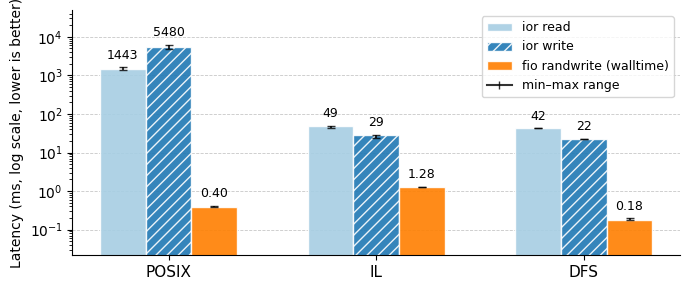

In [10]:
engines_order = ["POSIX", "IL", "DFS"]
paired = sns.color_palette("Paired", 12)

SERIES = [
    ("ior read",  "read",  "ior", paired[0], ""),     # light blue
    ("ior write", "write", "ior", paired[1], "///"),     # dark blue
    ("fio randwrite (walltime)", "write", "fio", paired[7], ""),
]

x     = np.arange(len(engines_order))
bar_w = 0.22
n_s   = len(SERIES)
offsets = np.linspace(-(n_s - 1) / 2, (n_s - 1) / 2, n_s) * bar_w

fig, ax = plt.subplots(figsize=(7, 3))

for offset, (label, access, source, color, hatch) in zip(offsets, SERIES):
    if source == "ior":
        sub = (
            lat_cmp_df[lat_cmp_df["access"] == access]
            .set_index("engine")
            .reindex(engines_order)
        )
        medians = sub["median_ms"].values
        mins    = sub["min_ms"].values
        maxs    = sub["max_ms"].values
    else:
        sub = fio_lat_stats.set_index("engine").reindex(engines_order)
        medians = sub["median_ms"].values
        mins    = sub["min_ms"].values
        maxs    = sub["max_ms"].values

    xs   = x + offset
    bars = ax.bar(xs, medians, width=bar_w, color=color, hatch=hatch,
                  label=label, edgecolor="white", alpha=0.9)
    ax.errorbar(xs, medians,
                yerr=[medians - mins, maxs - medians],
                fmt="none", ecolor="black", capsize=3, linewidth=1.5, alpha=0.8)

    for bar, val, mx in zip(bars, medians, maxs):
        fmt = f"{val:.2f}" if val < 10 else f"{val:.0f}"
        ax.annotate(
            fmt,
            xy=(bar.get_x() + bar.get_width() / 2, mx),
            xytext=(0, 4), textcoords="offset points",
            ha="center", va="bottom", fontsize=9, color="black",
        )

ax.set_xticks(x)
ax.set_xticklabels(engines_order, fontsize=11)
ax.set_yscale("log")
ax.set_ylabel("Latency (ms, log scale, lower is better)")
ax.margins(y=0.2)

from matplotlib.lines import Line2D
eb_handle = Line2D([0], [0], color="black", linewidth=1.5, alpha=0.8,
                   marker="|", markersize=6, label="min–max range")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + [eb_handle], labels + ["min–max range"], fontsize=9)

ax.yaxis.grid(True, which="major", linestyle="--", linewidth=0.6, alpha=0.7)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
plt.savefig("iorAndfio_engine-lat-cmp.pdf", bbox_inches="tight")
plt.show()